In [1]:
import torch
import matplotlib.pyplot as plt
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [2]:
# ─── Parameters ────────────────────────────────────────────────
R = .5                     # Circle radius
dt = 5e-3             # Time step
num_steps = 200           # Total steps
T = num_steps * dt          # Total time
num_particles = 10**7       # Reduced for performance
small_region_centers = torch.tensor([[-2., 0.5], [-2., 0.0]], device=device)
small_region_radius = 0.008  # Increased radius

In [3]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
weightsX0 = torch.tensor([0.227244, 0.243264, 0.272471, 0.257020], device=device)
mu_X0 = torch.tensor([
    [-1.343780, -0.917572],
    [-1.918041, 0.312022],
    [-1.409576, 0.881473],
    [-1.858740, -0.426247]
], device=device)
covariances_X0 = torch.tensor([
    [[0.047384, -0.012965],
     [-0.012965, 0.007892]],
    [[0.009571, 0.016151],
     [0.016151, 0.050525]],
    [[0.050269, 0.023060],
     [0.023060, 0.015863]],
    [[0.014982, -0.024017],
     [-0.024017, 0.053364]]
], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([0.299757, 0.221382, 0.232045, 0.246816], device=device)
mu_Xinf = torch.tensor([
    [1.435509, 0.851990],
    [1.882766, -0.437199],
    [1.948095, 0.265020],
    [1.352940, -0.899800]
], device=device)
covariances_Xinf = torch.tensor([
    [[0.062923, -0.032778],
     [-0.032778, 0.022120]],
    [[0.012416, 0.017986],
     [0.017986, 0.039130]],
    [[0.007053, -0.011705],
     [-0.011705, 0.051479]],
    [[0.050697, 0.017820],
     [0.017820, 0.011125]]
], device=device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

In [4]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [5]:
# Ensure no particles start inside the circle
norms = torch.norm(positions, dim=1)
inside = norms < R
if inside.any():
    positions[inside] = R * positions[inside] / norms[inside].unsqueeze(1)

# Select particles in the small region
centers = small_region_centers.size(1)
masks = torch.empty((num_particles, centers), dtype=torch.bool, device=device)
for center in range(centers):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks[:, center] = distances < small_region_radius
    num_selected = masks[:, center].sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()

# List to store average positions of selected particles
avg_positions = []
avg_pos = (masks.float().T @ positions) / masks.float().sum(dim=0).clamp(min=1).unsqueeze(1)
avg_positions.append(avg_pos)

Number of particles in small region: 382
Number of particles in small region: 2628


In [6]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, R)
final_positions, big_tensor = doSimulation(positions, masks, avg_positions, simParams, device)

t = 0.0000  |  Max drift: 601.8485  |  Mean drift: 363.8748
t = 0.2500  |  Max drift: 136.7175  |  Mean drift: 19.7806
t = 0.5000  |  Max drift: 147.7640  |  Mean drift: 19.3428
t = 0.7500  |  Max drift: 137.3210  |  Mean drift: 19.2273


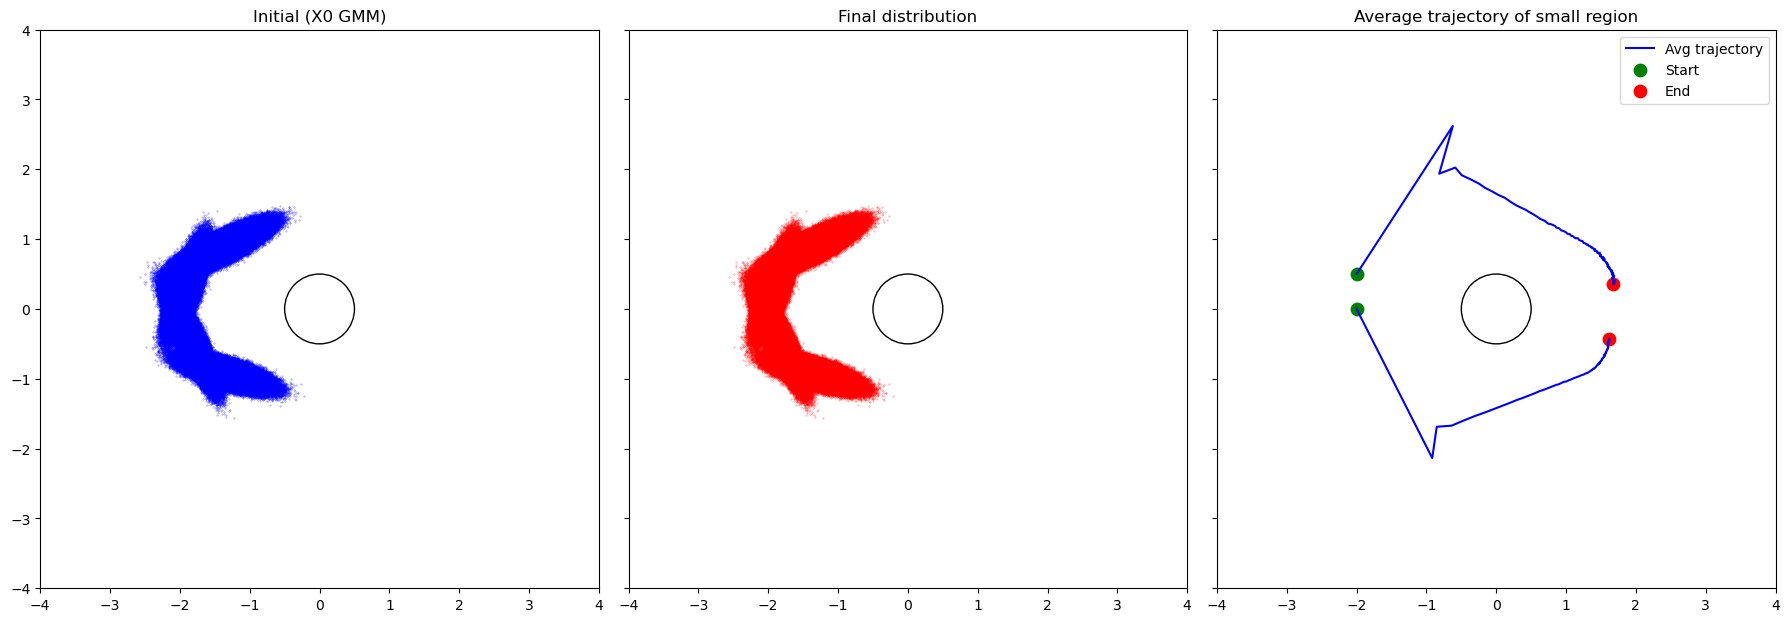

In [ ]:
# ─── Plotting ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-4., 4.)
    ax.set_ylim(-4., 4.)

# Initial
axes[0].scatter(initial_positions[:,0], initial_positions[:,1], s=0.1, alpha=0.5, color='blue')
axes[0].set_title('Initial (X0 GMM)')
axes[0].add_patch(plt.Circle((0,0), R, color='black', fill=False))

# Final
axes[1].scatter(final_positions[:,0], final_positions[:,1], s=0.1, alpha=0.5, color='red')
axes[1].set_title('Final distribution')
axes[1].add_patch(plt.Circle((0,0), R, color='black', fill=False))

# Trajectory
for center in range(centers):
    axes[2].plot(big_tensor[:, center, 0], big_tensor[:, center, 1], 'b-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[2].scatter(big_tensor[0, center, 0], big_tensor[0, center, 1], color='green', s=80, label='Start'  if center == 0 else None)
    axes[2].scatter(big_tensor[-1, center, 0], big_tensor[-1, center, 1], color='red', s=80, label='End'  if center == 0 else None)
axes[2].add_patch(plt.Circle((0,0), R, color='black', fill=False))
axes[2].set_title('Average trajectory of small region')
axes[2].legend()

plt.tight_layout()
plt.show()